# The Asset Diversification Effect

In [1]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-05-14 20:36:31.508 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [2]:
# Load data for the last 3 years
start_date = date.today() - relativedelta(years=3)
start_date

datetime.date(2023, 5, 14)

In [3]:
# Load ccollection of S&P500 stocks from repository
df_stocks = tad.get_sp500(start_date=start_date)

# We will be testing only on complete data across the time period
df_stocks = df_stocks.dropna(how='any', axis=1)

In [4]:
ht(df_stocks)

Price            Close                                                 \
Ticker               A        AAPL        ABBV         ABT       ACGL   
Date                                                                    
2023-05-15  125.101913  169.847397  132.737045  104.077560  71.412476   
2023-05-16  123.440262  169.847397  129.748886  103.651192  70.860954   
2023-05-17  124.886856  170.459381  129.803238  103.111092  69.453629   
2026-04-08  116.919998  258.899994  211.589996  103.559998  98.599998   
2026-04-09  115.389999  260.489990  212.399994  102.720001  98.839996   
2026-04-10  115.059998  260.480011  207.940002  100.300003  95.970001   

Price                                                                  ...  \
Ticker             ACN        ADBE         ADI        ADM         ADP  ...   
Date                                                                   ...   
2023-05-15  264.946198  345.670013  175.286011  68.914101  200.157028  ...   
2023-05-16  266.550171  345.109985  173.783844  66.671944  198.243149  ...   
2023-05-17  271.743927  356.630005  178.699112  66.580803  199.755600  ...   
2026-04-08  192.209991  239.309998  346.209991  71.720001  200.779999  ...   
2026-04-09  186.029999  229.940002  351.359985  70.349998  196.020004  ...   
2026-04-10  179.529999  225.350006  350.140015  69.730003  188.789993  ...   

Price         Volume                                                          \
Ticker           WTW         WY       WYNN        XEL         XOM        XYL   
Date                                                                           
2023-05-15  248000.0  2415600.0  2429200.0  1708600.0  13715600.0  1469100.0   
2023-05-16  323600.0  4424100.0  2382700.0  1770200.0  14795200.0  1603300.0   
2023-05-17  413700.0  4708200.0  5680500.0  2118000.0  14064700.0  1957400.0   
2026-04-08  574200.0  3955400.0  2548000.0  4283300.0  31311200.0  2933600.0   
2026-04-09  635600.0  3160900.0  1333300.0  3956200.0  25868400.0  2303600.0   
2026-04-10  921300.0  3719000.0   790900.0  3515400.0  21059600.0  1626900.0   

Price                                                  
Ticker            YUM        ZBH      ZBRA        ZTS  
Date                                                   
2023-05-15   896200.0   905300.0  235700.0  1060600.0  
2023-05-16  1572200.0   929400.0  183700.0  1175300.0  
2023-05-17  1690400.0  1071500.0  227400.0  1714500.0  
2026-04-08  1213500.0  2128500.0  788900.0  2635500.0  
2026-04-09  1184400.0  1712400.0  608100.0  2439100.0  
2026-04-10  1458400.0  1769300.0  552600.0  2384000.0  

[6 rows x 2185 columns]

In [5]:
# Dataset should be complete without any missing price points
df_stocks.isna().any().any()

np.False_

In [6]:
df_stocks.shape

(729, 2185)

In [7]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

437 stocks


## Simulating Portfolios

In [8]:
# The number of assets that will be included in the max portfolio
n_assets = 20
# The number of simulations per portfolio size
i_simulations = 1000
# Initialize lists that will form the final dataset
ewp_n_assets = []
ewp_run_num = []
ewp_tickers = []
ewp_risk = []
ewp_return = []
ewp_sharpe = []

# Number of assets in the portfolio
for n in range(1, n_assets+1):
    # Number of randomly allocated n sized portfolios to generate
    for i in range(1, i_simulations+1):

        # Generate a unique seed for each simulation so that results
        # are repeatable
        random.seed(i)
        f1 = random.randint(1, 1000)
        random.seed(n)
        f2 = random.randint(1, 1000)
        seed = f1*f2

        # Select a random portfolio of n assets from available stocks
        tickers = tao.select_n(n, df_stocks.columns.get_level_values(1).unique().tolist(), seed=seed)
        # Calculate equal weighted portfolio returns
        df_returns = tao.portfolio_returns(df_stocks.loc[:, pd.IndexSlice[:, tickers]], method='EWP')
        # Calculate summary statistics for the portfolio
        df_summary = tau.get_returns_summary(df_returns)

        # Store simulation values
        ewp_n_assets.append(n)
        ewp_run_num.append(i)
        ewp_tickers.append(tickers)
        ewp_risk.append(df_summary.loc['EWP', 'Risk'])
        ewp_return.append(df_summary.loc['EWP', 'Return'])
        ewp_sharpe.append(df_summary.loc['EWP', 'Sharpe'])
        
df_diversification = pd.DataFrame({'N Assets': ewp_n_assets, 
                                   'I Run': ewp_run_num, 
                                #    'tickers': ewp_tickers, 
                                   'Risk': ewp_risk, 
                                   'Return':ewp_return,
                                   'Sharpe': ewp_sharpe})

In [9]:
ht(df_diversification)

,N Assets,I Run,Risk,Return,Sharpe
0,1,1,0.373928,0.032007,0.085597
1,1,2,0.224116,0.252728,1.127669
2,1,3,0.230752,0.126707,0.549107
19997,20,998,0.164762,0.142123,0.862597
19998,20,999,0.152749,0.161282,1.055863
19999,20,1000,0.148614,0.093399,0.628467


Text(0.5, 0.015, 'Random portfolios converge toward a stable Sharpe distribution as asset count rises.')

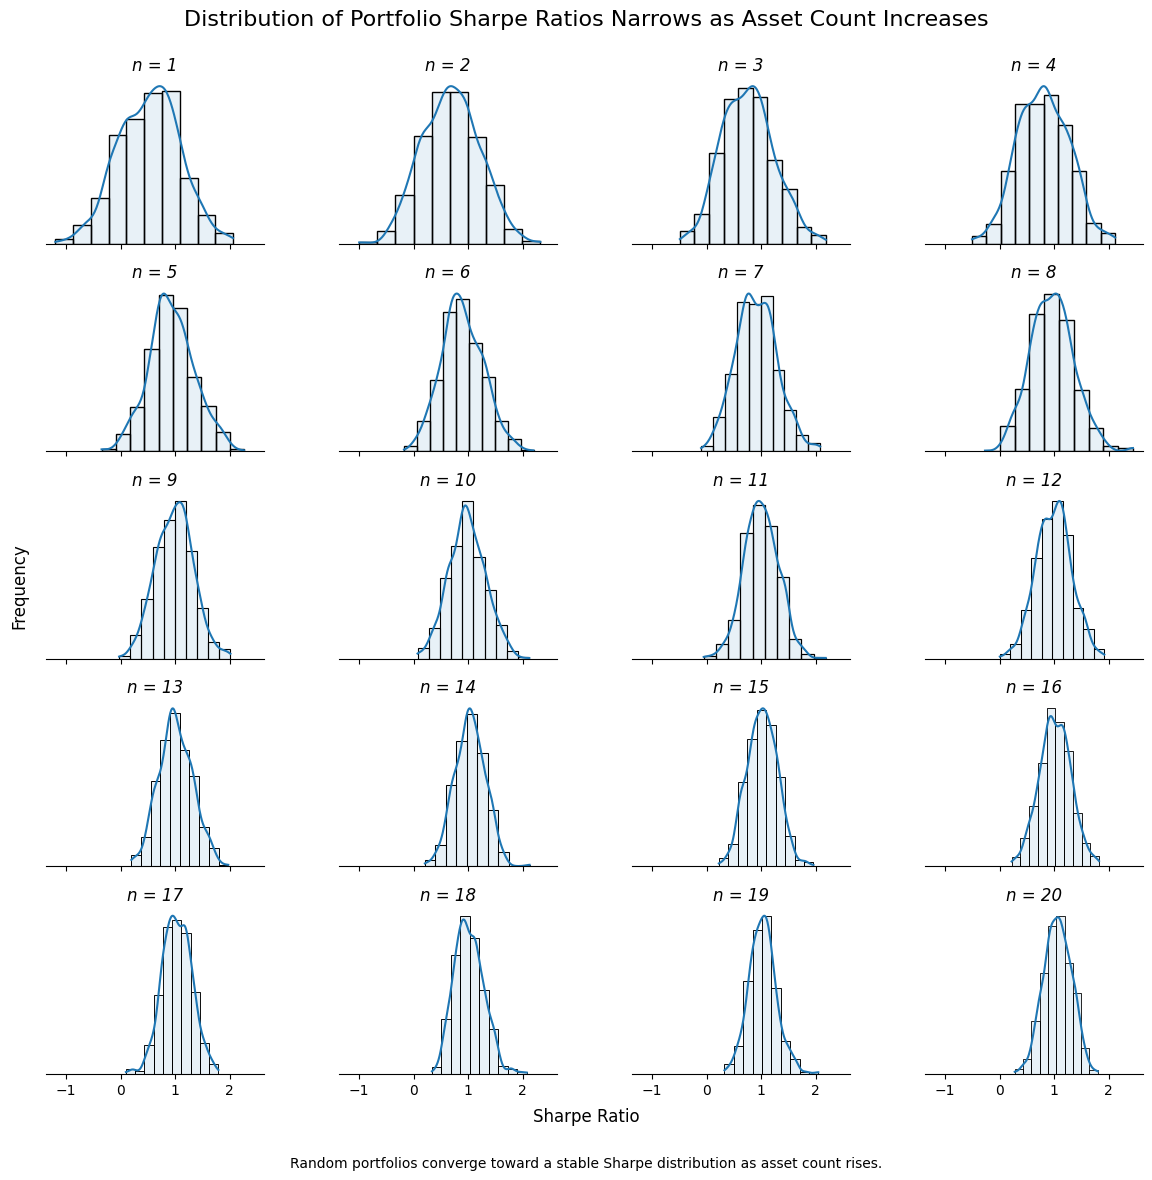

In [12]:
# 5 rows, 4 columns
r,c = 5,4
fig, ax = plt.subplots(r, c, figsize=(12, 12), tight_layout=True, sharex=True)

fig.tight_layout(pad=2, rect=[0,0.05,1,0.95])
fig.suptitle(f'Distribution of Portfolio Sharpe Ratios Narrows as Asset Count Increases',
             fontsize=16)
fig.supxlabel('Sharpe Ratio', y=0.05, fontsize=12)
fig.supylabel('Frequency', fontsize=12)

for n in df_diversification['N Assets'].unique():

    # Axes row
    ax_r = int(np.floor((n-1)/c))
    # Axes column
    ax_c = int((n-1)%c)
    # Axes subplot
    ax_p = ax[ax_r, ax_c]

    ax_p.set_title(f'n = {n}', fontsize=12, fontstyle='italic')
    ax_p.spines[['left','top', 'right']].set_visible(False)
    ax_p.set_yticklabels([])
    ax_p.set_yticks([])
    ax_p.set_ylabel(' ')
    ax_p.set_xlabel(' ')

    sns.histplot(
        df_diversification[df_diversification['N Assets']==n]['Sharpe'], 
        ax=ax_p,
        alpha=0.1,
        kde=True,
        bins=10
        )

footnote = 'Random portfolios converge toward a stable Sharpe distribution as asset count rises.'

fig.text(0.5,
         0.015,
         footnote,
         ha='center',
         wrap=True,
         fontsize=10)

In [13]:
df_grouped = df_diversification.groupby('N Assets').mean()[['Return', 'Risk', 'Sharpe']]
df_grouped.index = df_grouped.index.astype(str)
df_grouped

,Return,Risk,Sharpe
N Assets,,,
1,0.144671,0.284653,0.526145
2,0.155475,0.227343,0.687646
3,0.154244,0.203730,0.762137
4,0.150583,0.188018,0.804862
5,0.167879,0.179621,0.938476
6,0.155640,0.173849,0.895893
7,0.155568,0.170036,0.916903
8,0.160174,0.166509,0.965348
9,0.162131,0.163952,0.992132


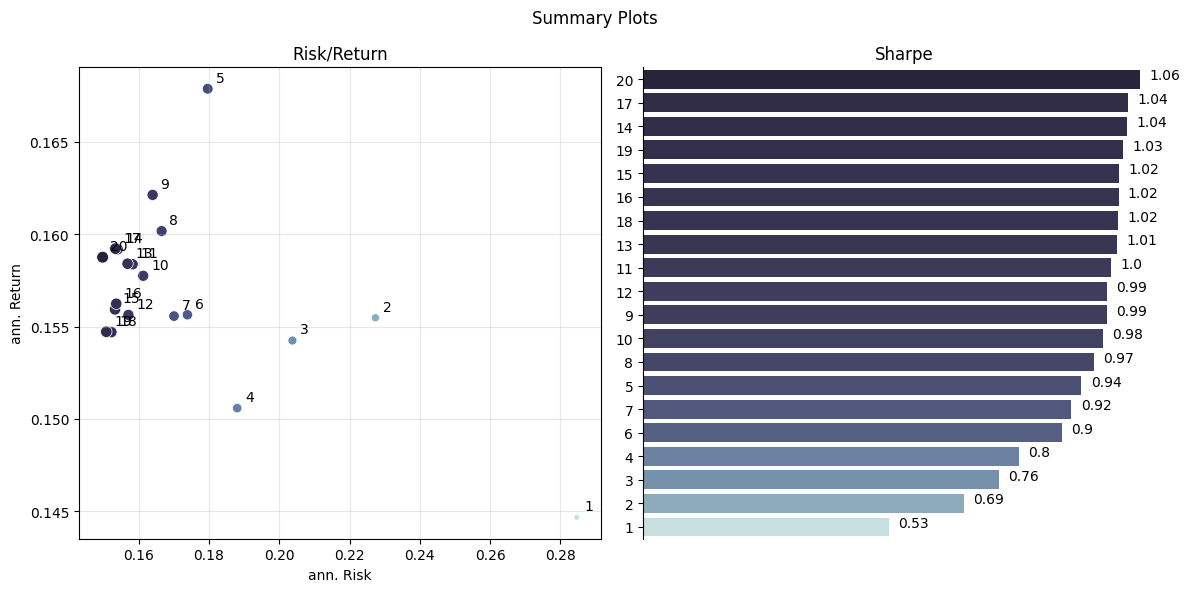

In [14]:
tap.plot_summary(df_grouped);

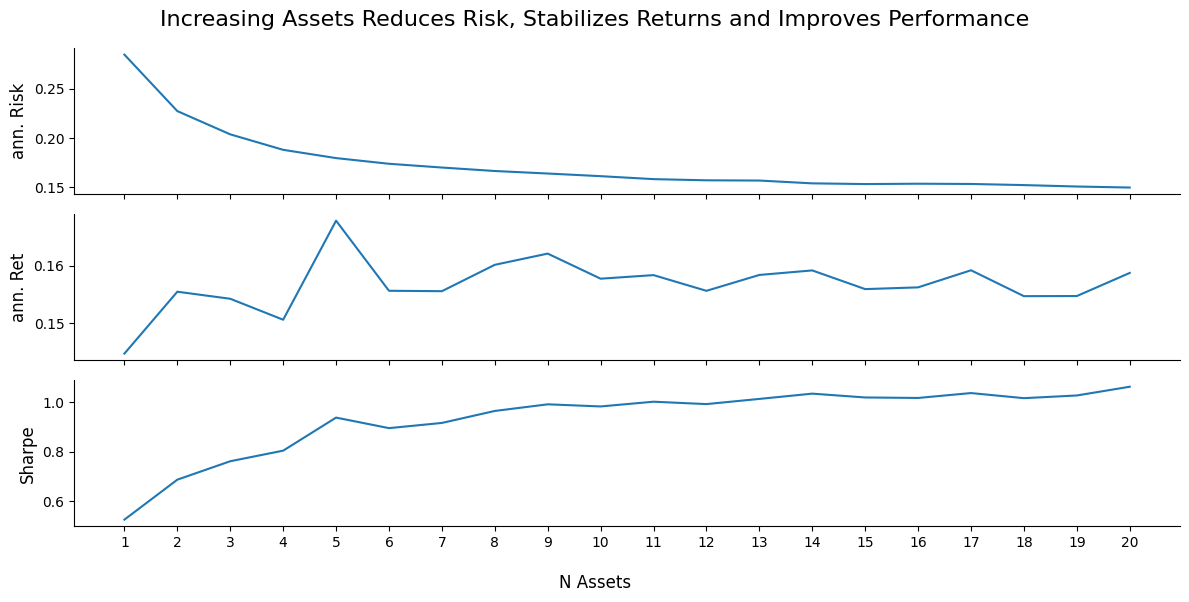

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(12, 6), tight_layout=True, sharex=True)

fig.suptitle('Increasing Assets Reduces Risk, Stabilizes Returns and Improves Performance', fontsize=16)
fig.supxlabel('N Assets')

ax[0].set_ylabel('ann. Risk',fontsize=12)
ax[0].set_xticks(np.arange(0,len(df_grouped)))
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].plot(df_grouped['Risk'])

ax[1].set_ylabel('ann. Ret',fontsize=12)
ax[1].set_xticks(np.arange(0,len(df_grouped)))
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].plot(df_grouped['Return'])

ax[2].set_ylabel('Sharpe',fontsize=12)
ax[2].set_xticks(np.arange(0,len(df_grouped)))
ax[2].spines[['top', 'right']].set_visible(False)
ax[2].plot(df_grouped['Sharpe'])

plt.show();